## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from frank2d import *
from frank.utilities import UVDataBinner

## Load data

In [2]:
dir = "../../data/uvtable/"
disk_name = "SimulatedBlob"
data_file = dir +"uvtable_SimulatedBlob.txt"

# Parameters for Geometry class, only for plotting purposes.
inc = 0
pa = 0
dra = 0
ddec = 0

rout = 1

# Load data
file = np.loadtxt(data_file, unpack =True)
u, v, Re, Im, Weights = file
Vis = Re + Im*1j
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

In [3]:
q = np.hypot(uvtable['u'], uvtable['v'])
Qmax = np.max(q)

Rmax = 3*rout
N = get_optimal_N(Rmax, Qmax)

print("N =", N)
print("Rmax =", Rmax)

N = 642
Rmax = 3


## Frank2D

<img src="../Static/Flowchart1.png" style="background-color:white;">

### Running the Fit

The fitting process can be executed in two different ways:


**1. With the Optimization Step**
The `fit` method in the `Frank2D` class includes a `find_MAP` parameter. Enabling this parameter triggers an optimization routine to find the Maximum A Posteriori (MAP) estimate, automatically determining the optimal Gaussian Process kernel parameters (hyperparameters) for your specific dataset.

**2. Without the Optimization Step**
If you already have a robust estimate of the kernel parameters—either from prior knowledge or from a previous run with the optimization enabled—you can bypass the MAP step. You can run the `fit` method directly by supplying your predetermined kernel parameters.

#### Additional Fit Parameters

To give you full control over the fitting process and the underlying iterative solver, the `fit` method includes several configurable parameters:

* **`data`** (`dict`, optional): Dictionary containing your visibility data (`u`, `v`, `vis`, `weights`). If not provided, the method uses the data already loaded into the class.
* **`initial_guess`** (`dict`): The starting hyperparameter values (e.g., `{'m': -2, 'p': -1, 'l': 1e4}`) used by the optimizer when `find_MAP=True`.
* **`kernel_type`** (`str`): The type of Gaussian Process kernel to use. Typical options are `'wend'` (Wendland) or `'sqexp'` (Squared Exponential).
* **`kernel_params`** (`dict`): The specific hyperparameters (amplitude and length scale) to use when `find_MAP=False`.
* **`method_name`** (`str`): The iterative solver method used to invert the matrix. The default is `'bicgstab'` (Biconjugate gradient stabilized method), but alternatives like `'cg'` can be used.
* **`method_func`** (`callable`, optional): A custom iterative solver function. If provided, this takes priority over `method_name`.
* **`x0`** (`array`, optional): An initial guess array for the iterative solver, which can help speed up convergence.
* **`maxiter`** (`int`): The maximum number of iterations allowed for the solver before stopping (default: `50000`).
* **`rtol`** (`float`): The relative tolerance required for the iterative solver to declare convergence (default: `1e-8`).
* **`precond_type`** (`str`): The type of preconditioner applied to accelerate the solver (e.g., `'jacobi'`).
* **`hermitian`** (`bool`): Enforces Hermitian symmetry in the visibilities, a fundamental property of real sky emission (default: `True`).
* **`run_from_scratch`** (`bool`): If `True`, resets all previous fitting settings and runs the fit completely fresh from the post-gridding stage.

In [4]:
frank2d = Frank2D(N, Rmax, verbose = True)

In [5]:
help(frank2d)

Help on Frank2D in module frank2d.cpu.frank2d object:

class Frank2D(builtins.object)
 |  Frank2D(N, Rmax, verbose=False, dev_mode=False)
 |
 |  Methods defined here:
 |
 |  __init__(self, N, Rmax, verbose=False, dev_mode=False)
 |      Initialize the Frank2D class.
 |      Parameters:
 |      -----------
 |      N : int
 |          Number of collocation points in each dimension (image will be NxN).
 |      Rmax : float
 |          Radius of the image in arcseconds.
 |      verbose : bool
 |          Whether to print detailed logs during the fitting process.
 |      dev_mode : bool
 |          Whether to run in development mode (for debugging and testing).
 |
 |  build_full_model(self)
 |      Build the full visibility model from the weighted and non-weighted solution.
 |      Return
 |      -------
 |      V_full : 2D array, unit: Jy
 |          Full visibility model on a Nx x Ny grid.
 |
 |  check_bounds(self, u, v)
 |      Function to check if the frequencies are within the bounds o

In [6]:
frank2d.fit(data = uvtable) # using m, c and l parameters by default.

===>  Setting gridded data...
===>  Setting GP Kernel wend...
         + Kernel parameters: {'m': -2, 'c': 100000000.0, 'l': 50000.0}
===>  Creating sparse linear system...
        +  Kernel = 0.03  min |  1.59 seconds
        +  Building system = 0.03  min |  1.64 seconds
===>  Solving linear system...


        +  Fitting:   0%|          | 172/50000 [00:13<1:04:32, 12.87 iterations/s]


        +  Fit info: 
              'CGM_converged': True,
               'Fit_correctly': True,
               'convergence_by': 'norm of r',
               'final_tol': 7.435963551417658,
               'iterations': 172,
               'maxiter': 50000,
               'preconditioner_method': 'jacobi',
               'rtol': 1e-08,
               'solver_method': 'bicgstab',
               'solver_time_sec': 13.394153594970703
===> Building full visibility model...
     + Setting kernel..


**Then, the solution is saved in the following two properties of Frank2D Class**

In [7]:
# Fourier space solution (NxN matrix)
vis_solution = frank2d.visibility_model

# coordinates 2d (NxN matrices)
u_2d = frank2d.u_grid
v_2d = frank2d.v_grid

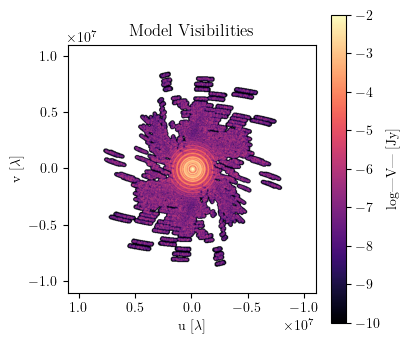

In [8]:
plt.figure(figsize=(4,4))
plt.imshow(np.log(np.abs(vis_solution)),
 extent=[u_2d.max(), u_2d.min(), v_2d.min(), v_2d.max()],
 cmap='magma',
 vmin=-10, vmax=-2
)
plt.xlabel(r'u [$\lambda$]')
plt.ylabel(r'v [$\lambda$]')
plt.colorbar(label='log|V| [Jy]')
plt.title('Model Visibilities')
plt.show()

In [9]:
# Image space solution (NxN matrix)
int_solution = frank2d.intensity_model

# Real plane 2d coordinates (NxN matrices)
x_2d = frank2d.x_grid
y_2d = frank2d.y_grid

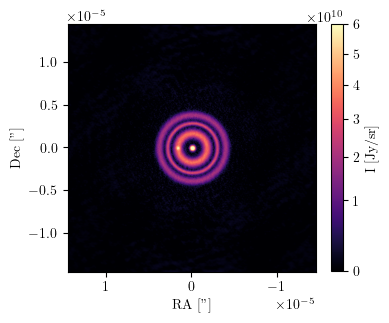

In [10]:
import matplotlib.colors as colors
norm = colors.PowerNorm(gamma = 0.7, vmin = 0, vmax = 6e10)

plt.figure(figsize=(4,4))
plt.imshow(int_solution, 
            extent=[x_2d.max(), x_2d.min(), y_2d.min(), y_2d.max()],
            norm=norm, 
            cmap = 'magma'
            )
plt.xlabel('RA ["]')
plt.ylabel('Dec ["]')
plt.colorbar(label='I [Jy/sr]', shrink=0.8)
plt.show()

### Frankenstein2D: Plot Class

To use the `Plot` class for visualization, you must provide it with your fitted `Frank2D` object, which contains both the modeled visibilities and the reconstructed intensity solutions. 

Additionally, you need to pass a `Geometry` object. Providing the geometry is essential, as it allows the `Plot` class to perform accurate deprojections or apply necessary phase corrections directly in the visibility space before plotting.

In [11]:
geom = Geometry(inc, pa, dra, ddec)
Plotter = Plot(frank2d, geom)

In [12]:
help(Plotter)

Help on Plot in module frank2d.cpu.plot object:

class Plot(builtins.object)
 |  Plot(Frank2D, Geometry, verbose=False)
 |
 |  Methods defined here:
 |
 |  __init__(self, Frank2D, Geometry, verbose=False)
 |      Class for plotting the results of Frank2D.
 |      Parameters
 |      ----------
 |      Frank2D : Frank2D object
 |          The Frank2D object containing the results of the model.
 |      Geometry : Geometry object
 |          The Geometry object for the source.
 |          This is necessary to apply phas shifts and deprojections.
 |
 |  calculate_resolution(self, clean_beam, intrinsic_resolution)
 |      Calculate the beam to convolve intrinsic resolution with,
 |      to obtain the CLEAN beam desired final resolution.
 |      Parameters
 |      ----------
 |      clean_beam : dict
 |          Dictionary containing the CLEAN beam parameters: 'bmaj', 'bmin', 'beam_pa'.
 |      intrinsic_resolution : float
 |          The intrinsic resolution to convolve with the CLEAN beam, 

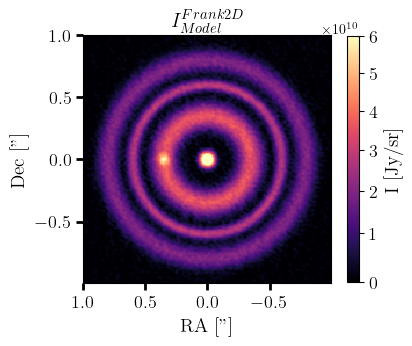

In [13]:
Plotter.intensity(fig_size=4, vmax=6e10, gamma = 0.9, zoom = 3, title = r'$I_{Model}^{Frank2D}$', title_size = 15)

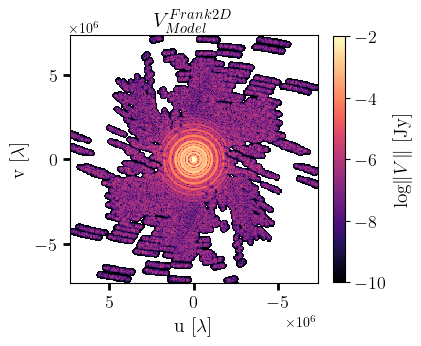

In [14]:
Plotter.visibility(fig_size=4, zoom = 1.5, title= r'$V_{Model}^{Frank2D}$', title_size = 15)

### The Optimization Step in Frankenstein2D

<img src="../Static/Flowchart2.png" style="background-color:white;">

The optimization step in Frankenstein2D, specifically the Frank2D module utilizing $N_{opt}$ and $R_{max}$, performs a Maximum a posteriori (MAP) estimation to find the optimal hyperparameters $\theta_{best}$ that best explain the gridded visibilities $V_{obs}$. 

To achieve this, we minimize the negative log-posterior $-\log(\theta | V_{obs})$ using Powell's method. Because we lack an analytical solution to efficiently compute $\log|D|$ and the inverse of $S$, we define our terms as in Frankenstein (Jennings et al. 2020):

- $D = (M + S)^{-1}$ acts as the precision matrix, which is the inverse of the total data covariance.
- $M$ represents the measurement noise.
- $S$ is the Gaussian Process covariance matrix (or kernel).

Here, $D$ is a fundamental component in evaluating the log-posterior, effectively weighting the data points based on their uncertainties and correlations. Without an analytical shortcut, we must build and store the full $M$ and $S$ matrices to compute the determinant directly at each iteration of Powell's method. Since evaluating these $N^{2} \times N^{2}$ matrices is highly computationally expensive, we restrict the optimization to a much smaller subset of data, enforcing $N_{opt} \ll N$.

##### The hyperparameters


The hypeparameters to be optimized during this step are those that define the Covariance Matrix ($\boldsymbol{\Sigma}$) of the Gaussian Process (GP) used in `Frankenstein2D`.

In the original Frankenstein1D, the covariance matrix in Fourier space is treated as **diagonal**. The values along this diagonal are defined as a vector of independent free parameters. It is only *after* the optimization process that one empirically observes that these optimized values naturally trace the 1D power spectrum of the data. 

`Frankenstein2D` leverages this empirical finding. Because we must account for the physical continuity of the astronomical source in 2D, we know that neighboring spatial frequencies in the *uv*-plane are intrinsically correlated. This requires a **non-diagonal** covariance matrix. However, optimizing every single element of a dense $N \times N$ matrix is computationally unfeasible. To solve this without an explosion of free parameters, `Frankenstein2D` parameterizes the covariance matrix using two main physical properties:

##### 1. Amplitude ($m$ and $c$)
Inspired by the empirical results of `Frankenstein1D`, we explicitly use the 1D power spectrum as a structural prior. We model the expected power spectrum $p(\mathbf{q})$ as a power-law, which equates to a straight line in log-log space—defined by a slope ($m$) and an intercept ($c$):

$$p(\mathbf{q}) = c \|\mathbf{q}\|^m$$

The amplitude for any pair of spatial frequency points $(i, j)$ in the covariance matrix is then defined analytically as the geometric mean of their respective power spectrum values:

$$\sigma_{ij}^2 = \sqrt{p(\mathbf{q}_i) p(\mathbf{q}_j)}$$

**Why this matters:** This formulation acts as a spectral envelope. It informs the model that the expected signal energy decays at longer baselines. By doing so, it prevents the GP from hallucinating false structures by attempting to fit thermal noise in high-frequency, signal-depleted regions.

##### 2. Correlation Length ($\ell$)
This parameter dictates the shape of the covariance matrix by defining the distance over which nearby points in the *uv*-plane remain correlated.  While standard Gaussian Processes often use a Squared Exponential (SE) kernel, the SE kernel produces a dense matrix because its correlations decay asymptotically but never truly reach zero. This makes matrix inversion computationally prohibitive, scaling as $O(N^3)$. 

To overcome this, `Frankenstein2D` utilizes a **Wendland kernel**. The defining feature of the Wendland kernel is its "compact support", meaning that any two points separated by a distance greater than the correlation length $\ell$ have exactly zero correlation.

**Why this matters:** By enforcing this strict cutoff at distance $\ell$, the Wendland kernel generates a **sparse covariance matrix**. This perfectly preserves the physical smoothness of the reconstructed source while drastically reducing the computational overhead and memory required to process large datasets.

#### How do we use this in the code?

To initialize the optimization step, you must provide the code with an initial guess for the hyperparameters. This guess is parameterized by four values, all defined in log-log space:

* `m`: The slope of the power-law spectrum.
* `l`: The characteristic length scale ($\ell$) of the kernel.
* `logp`: A reference spatial frequency point of your choosing, expressed in logarithmic space. For example, if you choose a baseline of px = $10^5 \lambda$, then `logq = 5`.
* `logq`: The corresponding logarithmic amplitude of the power spectrum at your chosen reference frequency. In other words, $p_y = powerspectrum(10^{px})$. For instance, you might estimate this value from your data to be roughly `logp = -0.5`.

By providing these four parameters, `Frankenstein2D` can construct the initial $m$ and $c$ values required to anchor the amplitude of the covariance matrix before the optimization routine begins.

In [15]:
# Analize power spectrum.
from frank.utilities import UVDataBinner       
bin_widths=[1e3, 1e5]

u, v = uvtable['u'], uvtable['v']
Vis = uvtable['vis']
Weights = uvtable['weights']

baselines = np.hypot(u, v)
binned_vis = UVDataBinner(baselines, Vis, Weights, bin_widths[0])
logx = np.log10(binned_vis.uv)
logy = np.log10(np.abs(binned_vis.V))

binned_vis2 = UVDataBinner(baselines, Vis, Weights, bin_widths[1])
logx2 = np.log10(binned_vis2.uv)
logy2 = np.log10(np.abs(binned_vis2.V))

lgx = np.log10(np.geomspace(np.sort(baselines)[1], baselines.max(), 1000))

cs, ms = ['#a4a4a4', 'k'], ['.', 'x']

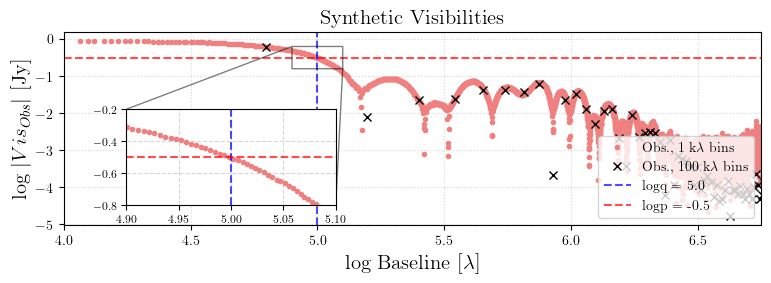

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 2.5)) 

ax.plot(logx, logy, marker=ms[0], ls='None', c='lightcoral', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
ax.plot(logx2, logy2, c=cs[1], marker=ms[1], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

ax.set_xlabel(r'log Baseline [$\lambda$]', size=15)
ax.set_ylabel(r'log $|Vis_{Obs}|$ [Jy]', size=15)
ax.set_title("Synthetic Visibilities", size=15)
ax.set_xlim(4.0, 6.75) 
ax.axvline(x=5.0, color='blue', linestyle='--', alpha=0.7, label = 'logq = 5.0')
ax.axhline(y=-0.5, color='red', linestyle='--', alpha=0.7, label = 'logp = -0.5')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, linestyle=':', alpha=0.5)

x_zoom_range = (4.9, 5.1)
y_zoom_range = (-0.8, -0.2)

axins = ax.inset_axes([0.09, 0.1, 0.3, 0.5]) 

axins.plot(logx, logy, marker=ms[0], ls='None', c='lightcoral')
axins.plot(logx2, logy2, c=cs[1], marker=ms[1], ls='None')
axins.axvline(x=5.0, color='blue', linestyle='--', alpha=0.7)
axins.axhline(y=-0.5, color='red', linestyle='--', alpha=0.7)

axins.set_xlim(x_zoom_range)
axins.set_ylim(y_zoom_range)
axins.grid(True, linestyle='--', alpha=0.5)
axins.tick_params(labelsize=8)

ax.indicate_inset_zoom(axins, edgecolor="black")

plt.show()

With the initial guess defined, we can proceed to run the optimization using the `search_MAP` method from the `Frank2D` class.

**Important Parameters for Optimization:**

* **`initial_guess`**: The dictionary containing the four starting parameters (`m`, `l`, `logq`, `logp`) discussed in the previous cell.
* **`N_opt`**: The number of collocation points used specifically for the optimization step. It is highly recommended that $N_{opt}$ be **less** than the global $N$ used for the final fit. Because the analytical math behind the optimization, specifically, evaluating the log marginal likelihood and its steps from Powell iterations, is computationally expensive, running this step at a lower resolution provides a much faster, yet still robust, estimation of the hyperparameters.

In [17]:
initial_guess = {'logp': -0.5, 'logq': 5,  'm': -1, 'l': 1e4}

 Also, instead, we could have used directly `frank2d.fit(find_MAP= True, initial_guess = guess)` 

In [18]:
frank2d.search_MAP(initial_guess= initial_guess, N_opt = 50)

[WARNING] Using existing visibility data...


===>  Setting MAP estimator...
===>  Searching for MAP...
         + MAP found: {'m': np.float64(-1.1178679332923875), 'c': np.float64(2113.9899790849863), 'l': np.float64(56438.659496007334)}


Expected execution on the fitting is mainly consumed by the parameter optimization step (taking ~93% to 98% of the total runtime). This time depends on the source complexity, the hardware, and the number of visibilities. For a standard uvtable of roughly 10^6 visibilities, average testing times for CPU vs. GPU setups on our datasets are:

* AS209: 18 min (CPU) / 15 min (GPU) for optimization, out of 19 min / 15 min total.

* Elias27: 28 min (CPU) / 13 min (GPU) for optimization, out of 30 min / 14 min total.

* Simulated Disk: 20.6 min (CPU) / 8.4 min (GPU) for optimization, out of 21 min / 8.5 min total.

In [19]:
frank2d.MAP

{'m': np.float64(-1.1178679332923875),
 'c': np.float64(2113.9899790849863),
 'l': np.float64(56438.659496007334)}

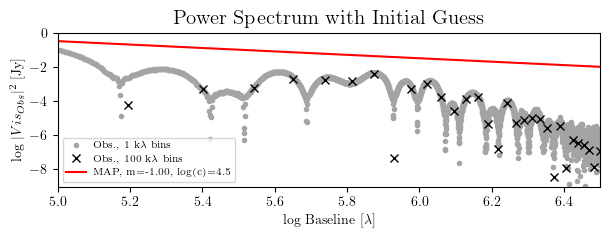

In [20]:
m = initial_guess['m']
c = 10**(initial_guess['logp'] - initial_guess['m']*initial_guess['logq'])
Plotter.power_spectrum(uvtable, m = m, c = c, title = r'Power Spectrum with Initial Guess', title_size = 15)

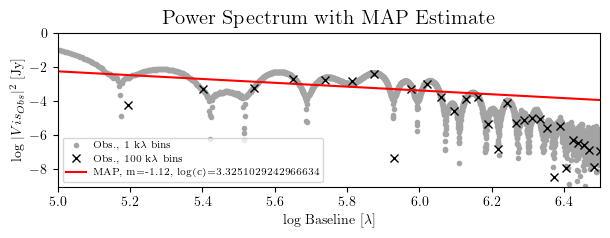

In [21]:
Plotter.power_spectrum(uvtable, frank2d.MAPEstimator, title = r'Power Spectrum with MAP Estimate', title_size = 15)

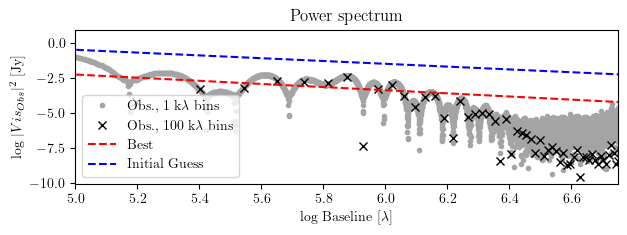

In [22]:
bin_widths=[1e3, 1e5]

u, v = uvtable['u'], uvtable['v']
Vis = uvtable['vis']
Weights = uvtable['weights']

baselines = np.hypot(u, v)
binned_vis = UVDataBinner(baselines, Vis, Weights, bin_widths[0])
logx = np.log10(binned_vis.uv)
logy = np.log10(np.abs(binned_vis.V)**2)

binned_vis2 = UVDataBinner(baselines, Vis, Weights, bin_widths[1])
logx2 = np.log10(binned_vis2.uv)
logy2 = np.log10(np.abs(binned_vis2.V)**2)

def linear_power_spectrum(logx, m, c):
    return m*logx + np.log10(c)

lgx = np.log10(np.geomspace(np.sort(baselines)[1], baselines.max(), 1000))

cs, ms = ['#a4a4a4', 'k'], ['.', 'x']

plt.figure(figsize=(7, 2))
plt.plot(logx, logy, c=cs[0], marker=ms[0], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
plt.plot(logx2, logy2, c=cs[1], marker=ms[1], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

lgy_best = linear_power_spectrum(lgx, frank2d.MAP['m'], frank2d.MAP['c'])
c = 10**(initial_guess['logp'] - initial_guess['logq']*initial_guess['m'])
lgy_ = linear_power_spectrum(lgx, initial_guess['m'], c)

plt.plot(lgx, lgy_best, 'r--', label='Best')
plt.plot(lgx, lgy_, 'b--', label='Initial Guess')

plt.xlabel(r'log Baseline [$\lambda$]', size = 10)
plt.ylabel(r'log $|Vis_{Obs}|^{2}$ [Jy]', size = 10)
plt.legend(loc = 'best', fontsize = 10)
plt.title("Power spectrum")
plt.xlim(5, 6.75)
plt.show()

#### Let's run another Frank2D object with best values

In [23]:
best_Nopt_50 = frank2d.MAP

In [24]:
frank2d.fit(data = uvtable, kernel_params = best_Nopt_50) 
# If you desire run from the beggining using another configuration in the
# Gridding step, you can turn on the run_from_scratch param of the fit method.

Using existing gridded data...
===>  Creating sparse linear system...
        +  Kernel = 0.03  min |  1.53 seconds
        +  Building system = 0.03  min |  1.58 seconds
===>  Solving linear system...


        +  Fitting:   0%|          | 172/50000 [00:13<1:04:32, 12.87 iterations/s]


        +  Fit info: 
              'CGM_converged': True,
               'Fit_correctly': True,
               'convergence_by': 'norm of r',
               'final_tol': 7.435963551417658,
               'iterations': 172,
               'maxiter': 50000,
               'preconditioner_method': 'jacobi',
               'rtol': 1e-08,
               'solver_method': 'bicgstab',
               'solver_time_sec': 13.382213354110718
===> Building full visibility model...
     + Setting kernel..


In [25]:
Plotter2 = Plot(frank2d, geom)

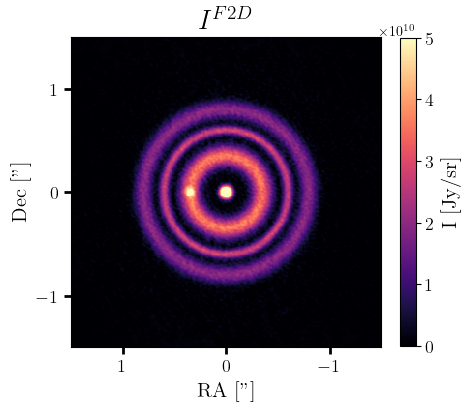

In [26]:
Plotter2.intensity(vmax=5e10, gamma = 1, zoom = 2, title = r'$I^{F2D}$', fig_size=5, label_size=15)

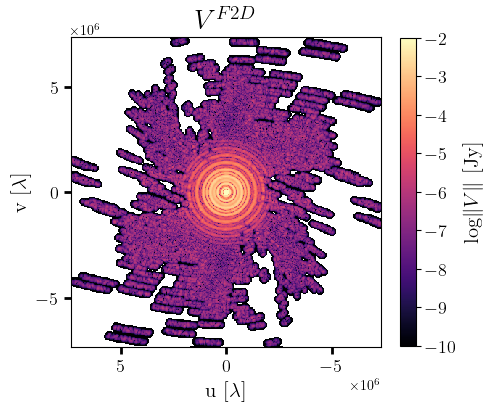

In [27]:
Plotter2.visibility(fig_size=5, zoom = 1.5, vmin = -10,  title = r'$V^{F2D}$', label_size=15)